# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **Previos step**:
  * all ETL steps from folder `/datasets_ETL`
  * Feature extraction step
**Machine Learning paradigm:** Supervised learning
* **Datasets**:
  * [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) - channel EEG Fpz-Cz
  * [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/) - channel EEG C3-A2
  * [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel) - channel EEG C4-M1
* **Models**: Machine Learning - Probabilistic models
* **Input**:
    * `ML_train_features.csv`
    * `ML_test_features.csv`
    * `ML_test_features.csv`
    * `generic_models_functions.py` - helper methods for the models
    * `generic_dataset_functions_ml.py` - helper methods for transforming the dataset



# Imports

In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import sys
import time
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PowerTransformer

In [ ]:
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/sleep_data'
helper_functions_path = base_path + '/helper_functions'

sys.path.append(helper_functions_path)

import utils as utils

Mounted at /content/drive


# Datasets

In [ ]:
df_train = pd.read_csv(base_path + '/process_dataset/extracted_features/train_features.csv')
df_val = pd.read_csv(base_path + '/process_dataset/extracted_features/val_features.csv')

X_train = df_train.drop(columns=['Label', 'Subject_ID'])
y_train = df_train['Label']

X_val = df_val.drop(columns=['Label', 'Subject_ID'])
y_val = df_val['Label']

## Standard Scalar

In [ ]:
scaler = StandardScaler()
X_train_enhanced_scaled = scaler.fit_transform(X_train.fillna(0))
X_val_enhanced_scaled = scaler.transform(X_val.fillna(0))

## Power Transformer

In [ ]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)

X_train_enhanced_pt = pt.fit_transform(X_train.fillna(0))
X_val_enhanced_pt   = pt.transform(X_val.fillna(0))

## PCA

In [ ]:
pca_gmm = PCA(n_components=40, random_state=42)

X_train_enhanced_pca = pca_gmm.fit_transform(X_train_enhanced_pt)
X_val_enhanced_pca   = pca_gmm.transform(X_val_enhanced_pt)

# Vitebri

In [ ]:
def calculate_transition_matrix(df_train, label_col='Label', subject_col='Subject_ID', n_classes=5):
    '''
     It models the probability of transitioning from one sleep stage to another.

    Parameters:
      - df_train (pd.DataFrame): DataFrame containing sleep stage labels.
      - label_col (str): Name of the column containing sleep stage labels.
      - subject_col (str): Name of the column containing subject IDs.

    Returns:
      - trans_mat (np.array): State transition matrix.
    '''
    trans_mat = np.ones((n_classes, n_classes))

    for subj, group in df_train.groupby(subject_col):
        labels = group[label_col].values

        for i in range(len(labels) - 1):
            current_state = int(labels[i])
            next_state = int(labels[i+1])
            trans_mat[current_state, next_state] += 1

    row_sums = trans_mat.sum(axis=1)
    trans_mat = trans_mat / row_sums[:, np.newaxis]

    return trans_mat

In [ ]:
def viterbi(obs_probs, trans_mat, start_prob):
    '''
    Adapted Viterbi algorithm to find the most likely "path" (sequence of sleep stages)
    using emission probabilities from a classifier (e.g. Logistic Regression).

    Parameters:
    - obs_probs (np.array): Matrix [n_epochs, n_classes] with probabilities from the model (predict_sample).
    - trans_mat (np.array): Transition matrix [n_classes, n_classes].
    - start_prob (np.array): Initial probabilities for each class.

    Returns:
    - best_path (np.array): Optimal sequence of stages (path with maximum probability).
    '''
    n_epochs, n_classes = obs_probs.shape

    eps = 1e-10
    log_start_prob = np.log(start_prob + eps)
    log_trans_mat = np.log(trans_mat + eps)
    log_obs_probs = np.log(obs_probs + eps)

    V = np.zeros((n_epochs, n_classes))
    ptr = np.zeros((n_epochs, n_classes), dtype=int)

    V[0, :] = log_start_prob + log_obs_probs[0, :]

    for t in range(1, n_epochs):
        for j in range(n_classes):
            seq_probs = V[t-1, :] + log_trans_mat[:, j] + log_obs_probs[t, j]

            V[t, j] = np.max(seq_probs)
            ptr[t, j] = np.argmax(seq_probs)

    best_path = np.zeros(n_epochs, dtype=int)

    best_path[-1] = np.argmax(V[-1, :])

    for t in range(n_epochs - 2, -1, -1):
        best_path[t] = ptr[t + 1, best_path[t+1]]

    return best_path

In [ ]:
def apply_viterbi_and_evaluate(obs_probs,df_val,y_val,fair_trans_mat,start_prob):
    '''
    Apply Viterbi algorithm to find the most likely "path" (sequence of sleep stages)
    using emission probabilities from a classifier (e.g. Logistic Regression).

    Parameters:
      - obs_probs (np.array): Matrix [n_epochs, n_classes] with probabilities from the model (predict_sample).
      - df_val (pd.DataFrame): DataFrame containing sleep stage labels.
      - y_val (pd.Series): Series containing sleep stage labels.
      - fair_trans_mat (np.array): Transition matrix [n_classes, n_classes].
      - start_prob (np.array): Initial probabilities for each class.

    Returns:
      - df_eval (pd.DataFrame): DataFrame with predicted sleep stages.
    '''
    df_eval = pd.DataFrame({
        'Subject_ID': df_val['Subject_ID'].reset_index(drop=True),
        'Label': y_val.reset_index(drop=True),
        'Pred_HMM': 0
    })

    # Apply Viterbi per subject
    for subj in df_eval['Subject_ID'].unique():
        idx = df_eval.index[df_eval['Subject_ID'] == subj]
        subj_probs = obs_probs[idx]
        best_path = viterbi(subj_probs, fair_trans_mat, start_prob)
        df_eval.loc[idx, 'Pred_HMM'] = best_path

    utils.evaluete_model(df_eval['Label'], df_eval['Pred_HMM'])

    return df_eval

# Models

## Logistic Regression + (lbfgs, C=0.5, balanced)

* best LR

Train time: 148.57 seconds
Accuracy 0.7102

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.75      0.78      0.76     10361
          N1       0.44      0.30      0.36      6930
          N2       0.80      0.73      0.76     20785
          N3       0.66      0.87      0.75      6474
         REM       0.67      0.81      0.74      7574

    accuracy                           0.71     52124
   macro avg       0.66      0.70      0.67     52124
weighted avg       0.70      0.71      0.70     52124



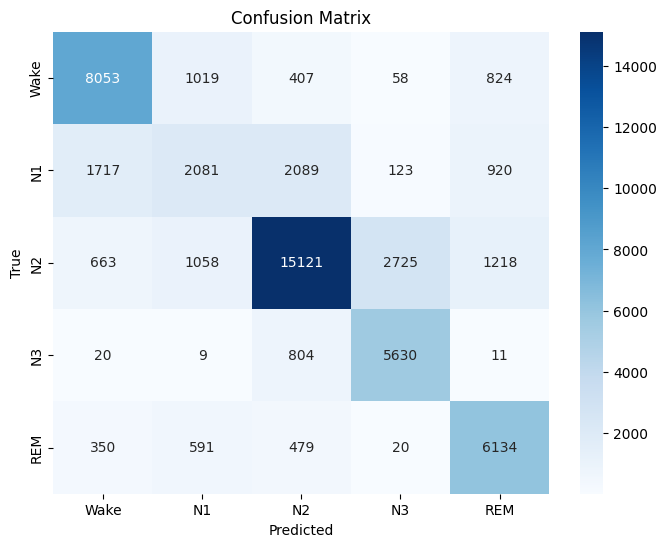

Cohen's Kappa: 0.6168330482460578


In [ ]:
lr_lbfgs = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    C=0.5,
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
lr_lbfgs.fit(X_train_enhanced_scaled, y_train)
end_time = time.time()
print(f"Train time: {end_time - start_time:.2f} seconds")

obs_probs_lr = lr_lbfgs.predict_proba(X_val_enhanced_scaled)

df_lr_lbfgs = apply_viterbi_and_evaluate(
    obs_probs_lr,df_val,y_val,fair_trans_mat,start_prob
    )

## Logistic Regression + (saga, C=0.6, balanced)

Train time: 9344.38 seconds
Accuracy 0.7086

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.74      0.78      0.76     10361
          N1       0.43      0.30      0.35      6930
          N2       0.80      0.73      0.76     20785
          N3       0.65      0.87      0.75      6474
         REM       0.67      0.81      0.73      7574

    accuracy                           0.71     52124
   macro avg       0.66      0.69      0.67     52124
weighted avg       0.70      0.71      0.70     52124



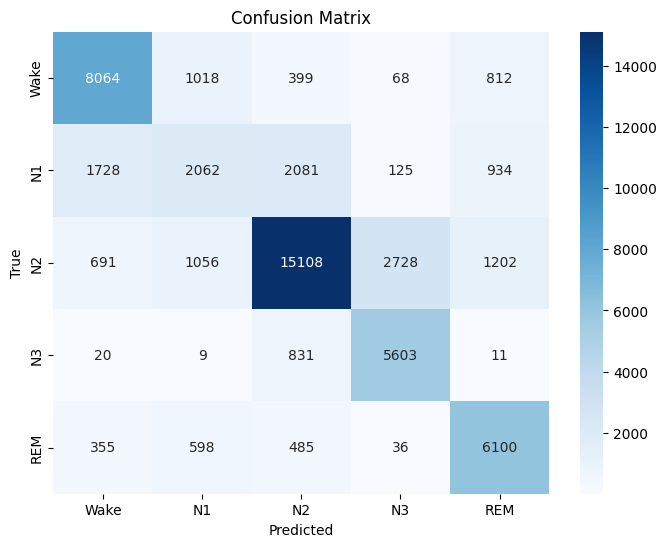

Cohen's Kappa: 0.6147133262814442


In [ ]:
lr_saga = LogisticRegression(
    class_weight='balanced',
    max_iter=8000,
    C=0.6,
    solver='saga',
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
lr_saga.fit(X_train_enhanced_scaled, y_train)
end_time = time.time()
print(f"Train time: {end_time - start_time:.2f} seconds")

obs_probs_lr = lr_saga.predict_proba(X_val_enhanced_scaled)

df_lr_saga = apply_viterbi_and_evaluate(
    obs_probs_lr,df_val,y_val,fair_trans_mat,start_prob
    )

## LDA (eigen, shrinkage=0.05, StandardScaler)

Train time: 5.33 seconds
Accuracy 0.7155

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.77      0.77      0.77     10361
          N1       0.48      0.19      0.27      6930
          N2       0.72      0.86      0.78     20785
          N3       0.73      0.69      0.71      6474
         REM       0.70      0.76      0.73      7574

    accuracy                           0.72     52124
   macro avg       0.68      0.65      0.65     52124
weighted avg       0.70      0.72      0.69     52124



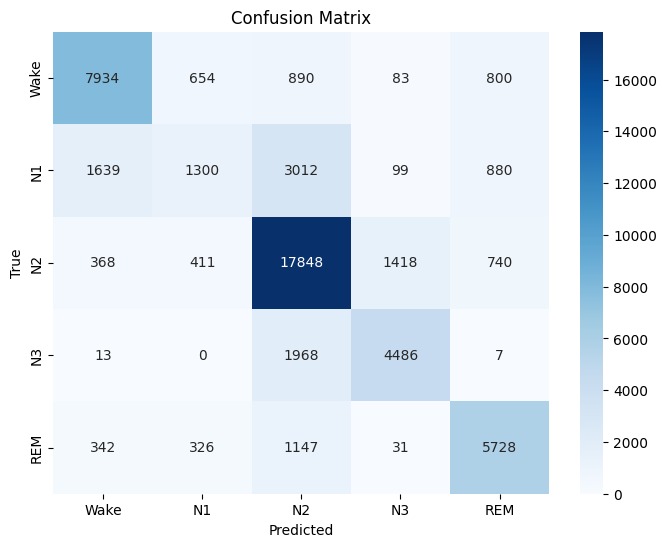

Cohen's Kappa: 0.6083435225992719


In [ ]:
lda_eigen = LinearDiscriminantAnalysis(
    solver='eigen',
    shrinkage=0.05
)

start_time = time.time()
lda_eigen.fit(X_train_enhanced_scaled, y_train)
end_time = time.time()
print(f"Train time: {end_time - start_time:.2f} seconds")

# Predict probabilities
obs_probs_lda = lda_eigen.predict_proba(X_val_enhanced_scaled)

# Transition matrix + Viterbi
trans_mat = calculate_transition_matrix(
    df_train_norm,
    label_col='Label',
    subject_col='Subject_ID'
)

fair_trans_mat = trans_mat.copy()
for i in range(5):
    fair_trans_mat[i, i] *= 0.6
    fair_trans_mat[i, :] /= fair_trans_mat[i, :].sum()

start_prob = np.array([0.90, 0.02, 0.02, 0.03, 0.03])

df_lda_eigen = apply_viterbi_and_evaluate(
    obs_probs_lda,df_val,y_val,fair_trans_mat,start_prob
    )

## LDA (lsqr, shrinkage='auto')

* best probabilistic model

Train time: 5.88 seconds
Accuracy 0.7167

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.76      0.77     10361
          N1       0.47      0.21      0.29      6930
          N2       0.72      0.86      0.78     20785
          N3       0.74      0.69      0.72      6474
         REM       0.70      0.76      0.73      7574

    accuracy                           0.72     52124
   macro avg       0.68      0.65      0.66     52124
weighted avg       0.70      0.72      0.70     52124



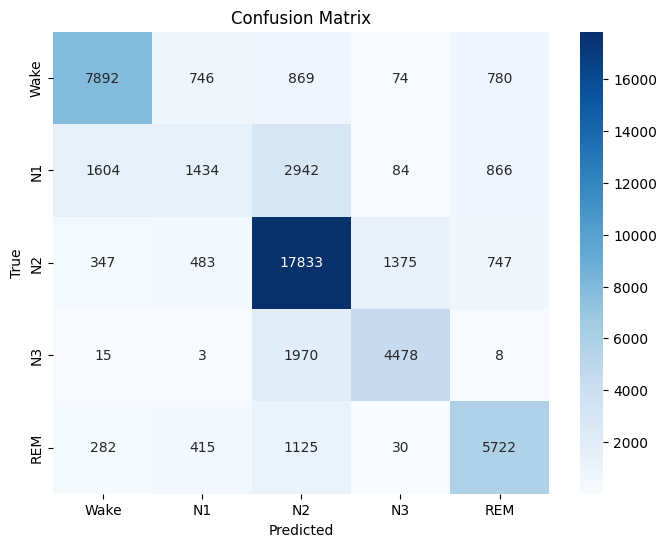

Cohen's Kappa: 0.6104550456850797


In [ ]:
lda_lsqr = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
start_time = time.time()
lda_lsqr.fit(X_train_enhanced_scaled, y_train)
end_time = time.time()
print(f"Train time: {end_time - start_time:.2f} seconds")

obs_probs_lda = lda_lsqr.predict_proba(X_val_enhanced_scaled)

df_lda_lsqr = apply_viterbi_and_evaluate(
    obs_probs_lda,df_val,y_val,fair_trans_mat,start_prob
    )